In [1]:
import os

folders = [
    "data/raw", "data/processed",
    "models",
    "notebooks",
    "src",
    "tests"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

with open("src/__init__.py", "w") as f:
    pass

print("Project structure created successfully.")

Project structure created successfully.


# A. Data Processing (`src/data_processing.py`)

In [2]:
# !pip install opendatasets

In [3]:
%%writefile src/data_processing.py
"""
Data processing module for Medical MNIST.
Handles downloading, preprocessing, and tf.data pipeline creation.
"""

import os
import tensorflow as tf
import opendatasets as od
from typing import Tuple

def load_medical_mnist(batch_size: int = 64, image_size: Tuple[int, int] = (64, 64)) -> Tuple[tf.data.Dataset, tf.data.Dataset]:
    """
    Downloads the Medical MNIST dataset and returns train/test tf.data.Datasets.

    Args:
        batch_size (int): The batch size for the datasets.
        image_size (Tuple[int, int]): Target size to resize images.

    Returns:
        Tuple[tf.data.Dataset, tf.data.Dataset]: Training and validation datasets.
    """
    dataset_url = "https://www.kaggle.com/datasets/andrewmvd/medical-mnist"
    od.download(dataset_url, data_dir="./data/raw")

    data_dir = "./data/raw/medical-mnist" # Actual path depends on extracted zip

    # Check if a nested folder exists
    if os.path.exists(os.path.join(data_dir, "medical-mnist")):
         data_dir = os.path.join(data_dir, "medical-mnist")

    dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels=None, # Unsupervised learning, we don't need labels for standard AE
        color_mode="grayscale",
        batch_size=batch_size,
        image_size=image_size,
        shuffle=True,
        validation_split=0.2,
        subset="both",
        seed=42
    )

    train_ds, val_ds = dataset

    # Normalize images to [0, 1] and map to (input, target) pairs for autoencoders
    def process_step(image: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
        image = tf.cast(image, tf.float32) / 255.0
        return image, image

    train_ds = train_ds.map(process_step, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(process_step, num_parallel_calls=tf.data.AUTOTUNE)

    return train_ds.prefetch(tf.data.AUTOTUNE), val_ds.prefetch(tf.data.AUTOTUNE)

def add_noise(image: tf.Tensor, factor: float = 0.2) -> tf.Tensor:
    """Adds random Gaussian noise to an image tensor."""
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=factor)
    noisy_image = image + noise
    return tf.clip_by_value(noisy_image, 0.0, 1.0)

Overwriting src/data_processing.py


# B. Model Architectures (`src/model.py`)

In [4]:
%%writefile src/model.py
"""
Model module containing Autoencoder (AE) and Variational Autoencoder (VAE) architectures.
"""

import tensorflow as tf
from tensorflow.keras import layers, Model
from typing import Tuple

class MedicalAE(Model):
    """Standard Convolutional Autoencoder."""

    def __init__(self, latent_dim: int):
        super(MedicalAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(64, 64, 1)),
            layers.Conv2D(32, 3, activation='relu', strides=2, padding='same'),
            layers.Conv2D(64, 3, activation='relu', strides=2, padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu')
        ], name="encoder")

        self.decoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(16 * 16 * 64, activation='relu'),
            layers.Reshape((16, 16, 64)),
            layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same'),
            layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same'),
            layers.Conv2D(1, 3, activation='sigmoid', padding='same')
        ], name="decoder")

    def call(self, x: tf.Tensor) -> tf.Tensor:
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


class MedicalVAE(Model):
    """Variational Autoencoder with probabilistic latent space."""

    def __init__(self, latent_dim: int):
        super(MedicalVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder outputs both mean and log variance
        self.encoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(64, 64, 1)),
            layers.Conv2D(32, 3, activation='relu', strides=2, padding='same'),
            layers.Conv2D(64, 3, activation='relu', strides=2, padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim + latent_dim) # mean and logvar
        ], name="vae_encoder")

        self.decoder = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim,)),
            layers.Dense(16 * 16 * 64, activation='relu'),
            layers.Reshape((16, 16, 64)),
            layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same'),
            layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same'),
            layers.Conv2D(1, 3, activation='sigmoid', padding='same')
        ], name="vae_decoder")

    def encode(self, x: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean: tf.Tensor, logvar: tf.Tensor) -> tf.Tensor:
        eps = tf.random.normal(shape=tf.shape(mean))
        return eps * tf.exp(logvar * 0.5) + mean

    def call(self, x: tf.Tensor) -> tf.Tensor:
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        reconstructed = self.decoder(z)

        # KL Divergence Loss
        kl_loss = -0.5 * tf.reduce_mean(1 + logvar - tf.square(mean) - tf.exp(logvar))
        self.add_loss(kl_loss)
        # Removed: self.add_metric(kl_loss, name="kl_loss", aggregation="mean") # This line caused the error

        return reconstructed

Overwriting src/model.py


`experiment.ipynb`

## Import Modules & Data

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from src.data_processing import load_medical_mnist, add_noise
from src.model import MedicalAE, MedicalVAE

# Load Data
train_ds, val_ds = load_medical_mnist(batch_size=64)

# Create a noisy dataset for denoising demonstration
def map_to_noisy(img, target):
    return add_noise(img, factor=0.2), target

noisy_train_ds = train_ds.map(map_to_noisy)
noisy_val_ds = val_ds.map(map_to_noisy)

Skipping, found downloaded files in "./data/raw/medical-mnist" (use force=True to force download)
Found 58954 files.
Using 47164 files for training.
Using 11790 files for validation.


## Train the Standard Autoencoder

In [6]:
LATENT_DIM = 64
EPOCHS = 10

ae_model = MedicalAE(latent_dim=LATENT_DIM)
ae_model.compile(optimizer='adam', loss='mse')

print("Training Standard AE...")
ae_history = ae_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)
ae_model.save_weights('./models/ae_model.weights.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Training Standard AE...
Epoch 1/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0155 - val_loss: 0.0081
Epoch 2/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0073 - val_loss: 0.0067
Epoch 3/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0063 - val_loss: 0.0061
Epoch 4/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0058 - val_loss: 0.0057
Epoch 5/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 6/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 7/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0051 - val_loss: 0.0052
Epoch 8/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0050 - val_loss: 0.0051
Epoch 9/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0048 - val_loss: 0.0050
Epoch 10/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0047 - val_loss: 0.0050


## Train the Variational Autoencoder

In [7]:
vae_model = MedicalVAE(latent_dim=LATENT_DIM)
# Note: The KL loss is added internally in the call() method.
# We compile with MSE to handle the reconstruction loss portion.
vae_model.compile(optimizer='adam', loss='mse')

print("Training VAE...")
vae_history = vae_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)
vae_model.save_weights('./models/vae_model.weights.h5')

Training VAE...
Epoch 1/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0624 - val_loss: 0.0565
Epoch 2/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0551 - val_loss: 0.0544
Epoch 3/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0540 - val_loss: 0.0539
Epoch 4/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0535 - val_loss: 0.0535
Epoch 5/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.0531 - val_loss: 0.0532
Epoch 6/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0529 - val_loss: 0.0530
Epoch 7/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0528 - val_loss: 0.0533
Epoch 8/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0526 - val_loss: 0.0528
Epoch 9/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0524 - val_loss: 0.0527
Epoch 10/10
737/737 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0524 - val_loss: 0.0526


## Visualizing Reconstructions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


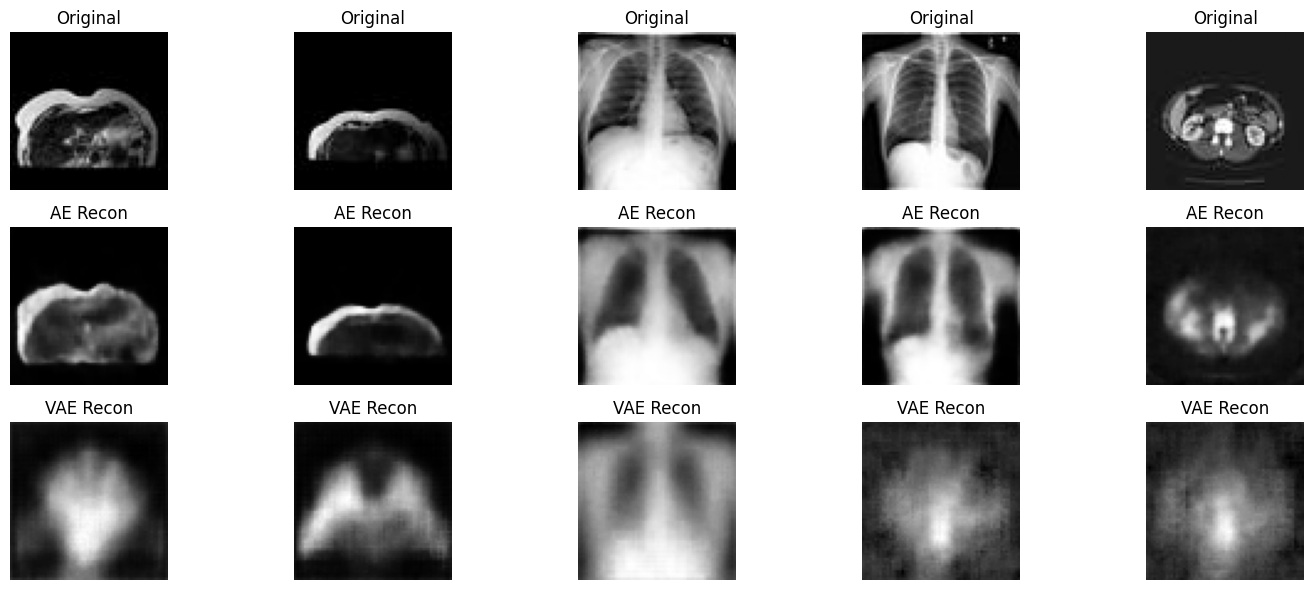

In [8]:
# Grab a single batch for visualization
for batch, _ in val_ds.take(1):
    test_images = batch[:5]
    break

ae_reconstructions = ae_model.predict(test_images)
vae_reconstructions = vae_model.predict(test_images)

plt.figure(figsize=(15, 6))
for i in range(5):
    # Original
    plt.subplot(3, 5, i + 1)
    plt.imshow(tf.squeeze(test_images[i]), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # AE
    plt.subplot(3, 5, i + 6)
    plt.imshow(tf.squeeze(ae_reconstructions[i]), cmap='gray')
    plt.title("AE Recon")
    plt.axis('off')

    # VAE
    plt.subplot(3, 5, i + 11)
    plt.imshow(tf.squeeze(vae_reconstructions[i]), cmap='gray')
    plt.title("VAE Recon")
    plt.axis('off')
plt.tight_layout()
plt.show()

# VAE Generation (Sampling from Latent Space)

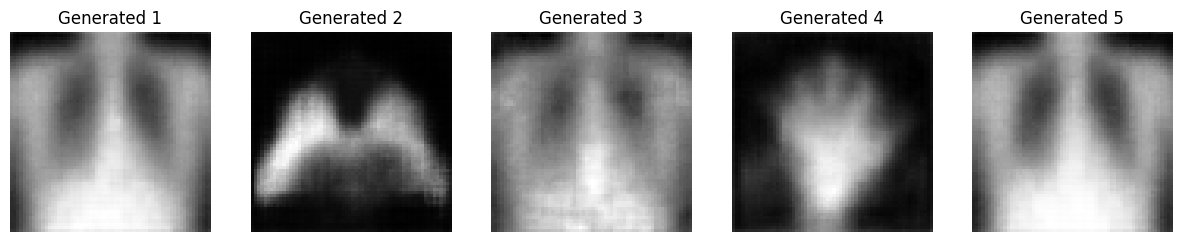

In [9]:
# Generate new random samples from a unit Gaussian
random_latent_vectors = tf.random.normal(shape=(5, LATENT_DIM))
generated_images = vae_model.decoder(random_latent_vectors)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(tf.squeeze(generated_images[i]), cmap='gray')
    plt.title(f"Generated {i+1}")
    plt.axis('off')
plt.show()

`Abdalla Tamer ✅`